# Generation Plot for Focus Countries from PyPSA-Eur Network

## 1. Import Packages

In [3]:
import pandas as pd
import pypsa
import pycountry
import matplotlib.pyplot as plt
import numpy as np
import os

from itertools import combinations

## 2. Load Data

In [4]:
year = 2023
network_path ="C:\\Users\\user\\Pictures\\Ember-Flexibility-Study\\results\\scenario_2030_flex_on\\networks\\base_s_39__23H_2030.nc"

countries = ['DE', 'NL', 'IT', 'PL', 'CZ', 'GR']

color_dict = {
   "Bioenergy": "#baa741",
"Gas": "#e05b09",
"Hard coal": "#545454",
"Hydro": "#298c81",
"Lignite": "#826837",
"Nuclear": "#ff8c00",
"Offshore wind": "#6895dd",
"Onshore wind": "#235ebc",
"Other fossil": "#000000",
"Other renewables": "#e3d37d",
"Solar": "#f9d002",
"solar rooftop": "#90ee90"
}

n = pypsa.Network(network_path)

INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## 3. Process PyPSA Generation Data

In [5]:
def process_pypsa_generation_sector():
    pypsa_to_ember = {
        "Bioenergy": "Bioenergy", "urban central solid biomass CHP": "Bioenergy",
        "urban central solid biomass CHP CC": "Bioenergy",
        "gas": "Gas", "Gas": "Gas", "CCGT": "Gas", "OCGT": "Gas", "urban central gas CHP": "Gas",
        "urban central gas CHP": "Gas", "urban central gas CHP CC": "Gas",
        "coal": "Hard coal", "Hard coal": "Hard coal","urban central coal CHP": "Hard coal", 
        "lignite": "Lignite", "Lignite": "Lignite", "urban central lignite CHP":"Lignite", 
        "hydro": "Hydro", "Hydro": "Hydro", "PHS": "Hydro", "ror": "Hydro",
        "Nuclear": "Nuclear", "nuclear": "Nuclear",
        "offwind-ac": "Offshore wind", "offwind-dc": "Offshore wind",
        "offwind-float": "Offshore wind", "Offshore wind": "Offshore wind",
        "onwind": "Onshore wind", "Onshore wind": "Onshore wind",
        "oil": "Other fossil", "Other fossil": "Other fossil",
        "geothermal": "Other renewables", "Other renewables": "Other renewables",
        "solar": "Solar", "solar-hsat": "Solar", "Solar": "Solar", 
    }

    gen_meta = n.generators[["bus", "carrier"]].copy()
    gen_meta.loc[:, "country"] = gen_meta["bus"].str[:2]
   
    vres_carriers = ['offwind-dc', 'offwind-ac', 'solar', 'solar-hsat', 'offwind-float', 'onwind', 'ror', 'solar rooftop'] # ideally this is not hardcoded !
    vres =  n.generators.query("carrier in @vres_carriers").index
    gen_energy = n.generators_t.p[vres].multiply(n.snapshot_weightings.generators, axis=0).sum(axis=0) / 1e6  # MWh to TWh
    gen_energy = gen_energy.clip(lower=0)
    gen_energy.index.name = "generator"
    gen_energy = gen_energy.reset_index().rename(columns={0: "Value"})
    gen_energy = gen_energy.merge(gen_meta, left_on="generator", right_index=True)
    gen_grouped = gen_energy.groupby(["country", "carrier"], as_index=False)["Value"].sum()
    gen_grouped["Ember_Variable"] = gen_grouped["carrier"].map(pypsa_to_ember).fillna(gen_grouped["carrier"])
    gen_renamed = gen_grouped.groupby(["country", "Ember_Variable"], as_index=False)["Value"].sum()
    gen_renamed = gen_renamed.rename(columns={"country": "ISO", "Ember_Variable": "Variable"})

    
    conv_buses = list(
        n.generators.query("carrier in ['gas', 'coal', 'uranium', 'lignite', 'biomass', 'oil', 'solid biomass', 'unsustainable solid biomass']").bus
    )
    AC_buses = n.buses.query("carrier == 'AC'").index
    link_meta = n.links[["bus1", "carrier"]].copy()
    link_meta.loc[:, "country"] = link_meta["bus1"].str[:2]

    gen_links = n.links.query("bus0 in @conv_buses and bus1 in @AC_buses").index
    gen_energy_links = (-n.links_t.p1[gen_links]).multiply(n.snapshot_weightings.generators, axis=0).sum(axis=0) / 1e6
    gen_energy_links = gen_energy_links.clip(lower=0)
    gen_energy_links.index.name = "links"
    gen_energy_links = gen_energy_links.reset_index().rename(columns={0: "Value"})
    gen_energy_links = gen_energy_links.merge(link_meta, left_on="links", right_index=True)
    gen_grouped_links = gen_energy_links.groupby(["country", "carrier"], as_index=False)["Value"].sum()
    gen_grouped_links["Ember_Variable"] = gen_grouped_links["carrier"].map(pypsa_to_ember).fillna(gen_grouped_links["carrier"])
    gen_renamed_links = gen_grouped_links.groupby(["country", "Ember_Variable"], as_index=False)["Value"].sum()
    gen_renamed_links = gen_renamed_links.rename(columns={"country": "ISO", "Ember_Variable": "Variable"})
    sto_meta = n.storage_units[["bus", "carrier"]].copy()
    sto_meta.loc[:, "country"] = sto_meta["bus"].str[:2]
    sto_energy = n.storage_units_t.p.clip(lower=0).multiply(n.snapshot_weightings.stores, axis=0).sum(axis=0) / 1e6  # MWh to TWh
    sto_energy.index.name = "storage_unit"
    sto_energy = sto_energy.reset_index().rename(columns={0: "Value"})
    sto_energy = sto_energy.merge(sto_meta, left_on="storage_unit", right_index=True)
    sto_grouped = sto_energy.groupby(["country", "carrier"], as_index=False)["Value"].sum()
    sto_grouped["Ember_Variable"] = sto_grouped["carrier"].map(pypsa_to_ember).fillna(sto_grouped["carrier"])
    sto_renamed = sto_grouped.groupby(["country", "Ember_Variable"], as_index=False)["Value"].sum()
    sto_renamed = sto_renamed.rename(columns={"country": "ISO", "Ember_Variable": "Variable"})

    gen_and_sto = pd.concat([gen_renamed, gen_renamed_links, sto_renamed], ignore_index=True)
    gen_and_sto = gen_and_sto.groupby(["ISO", "Variable"], as_index=False)["Value"].sum()
    gen_and_sto['Value'] = gen_and_sto['Value'].clip(lower=0)
    gen_and_sto = gen_and_sto[gen_and_sto['Value'] > 0]
    gen_and_sto = gen_and_sto[gen_and_sto['ISO'].isin(countries)] 
    return gen_and_sto.set_index(["ISO", "Variable"])

pypsa_generation = process_pypsa_generation_sector()

## 4. Plot Generation Data

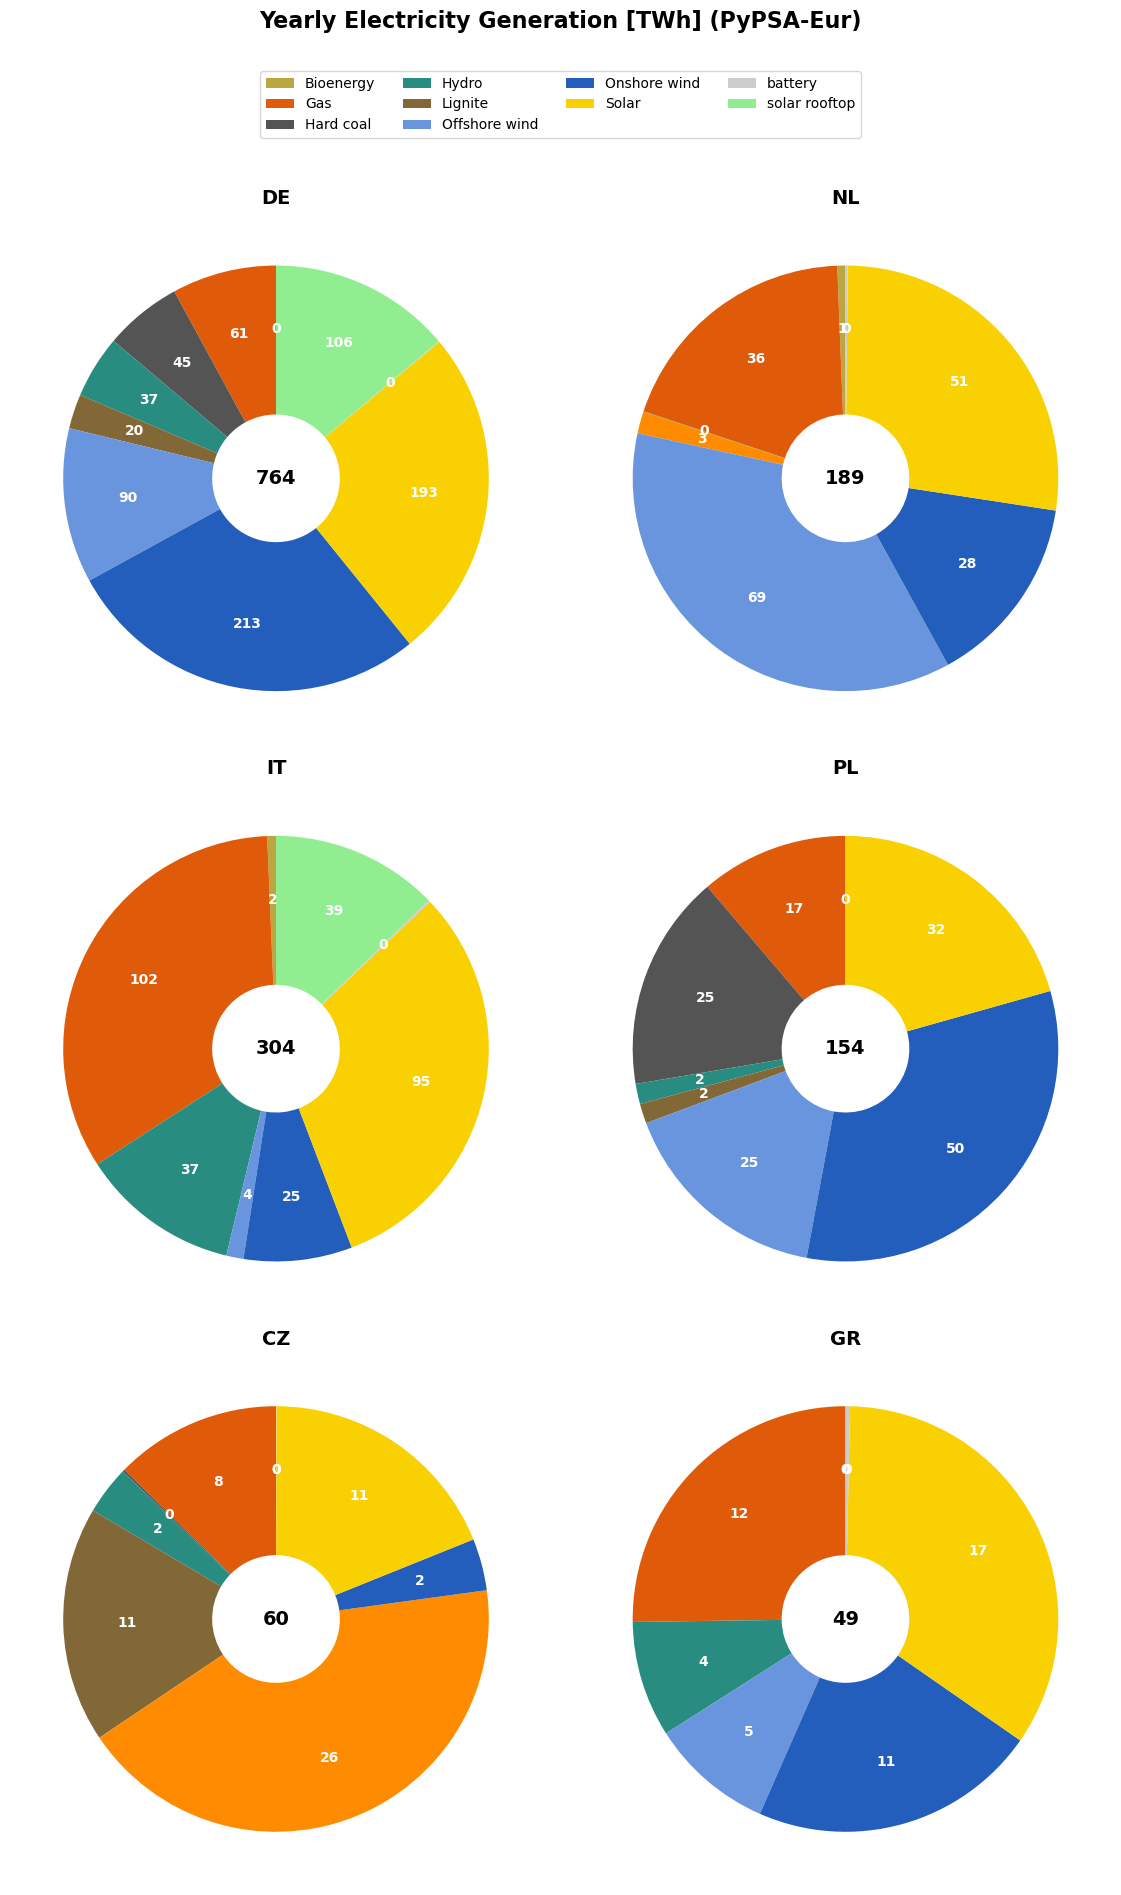

In [6]:
def plot_country_generation_mix_donut(df, country_isos, color_dict):
    n = len(country_isos)
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(12, 6 * rows))
    plt.subplots_adjust(wspace=0.05)
    axes = axes.flatten()
    legend_handles = []
    legend_labels = []
    def pivot(df):
        p = df.pivot(index='ISO', columns='Variable', values='Value').fillna(0)
        return p
    pivot_df = pivot(df)
    for idx, country_iso in enumerate(country_isos):
        ax = axes[idx]
        if country_iso not in pivot_df.index:
            ax.axis('off')
            ax.set_title(f"{country_iso} not found")
            continue
        data = pivot_df.loc[country_iso]
        data = data[data > 0]
        colors = [color_dict.get(tech, "#cccccc") for tech in data.index]
        wedges, _ = ax.pie(
            data.values,
            labels=None,
            startangle=90,
            colors=colors,
            wedgeprops=dict(width=0.7),
            autopct=None
        )
        for i, wedge in enumerate(wedges):
            angle = (wedge.theta2 + wedge.theta1) / 2
            x = 0.7 * np.cos(np.deg2rad(angle))
            y = 0.7 * np.sin(np.deg2rad(angle))
            ax.text(x, y, f"{data.values[i]:.0f}", ha='center', va='center', fontsize=10, color='white', fontweight='bold')
        centre_circle = plt.Circle((0, 0), 0.25, color='white', fc='white', linewidth=0)
        ax.add_artist(centre_circle)
        total = data.sum().round()
        ax.text(0, 0, f"{total:.0f}", ha='center', va='center', fontsize=14, fontweight='bold')
        ax.set_title(f"{country_iso}", fontsize=14, fontweight='bold')
        if idx == 0:
            legend_handles = wedges
            legend_labels = data.index
    for i in range(n, len(axes)):
        axes[i].axis('off')
    fig.legend(
        legend_handles, legend_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        fontsize=10,
        frameon=True
    )
    fig.suptitle("Yearly Electricity Generation [TWh] (PyPSA-Eur)", fontsize=16, weight='bold', y=1.05)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

df = pypsa_generation.reset_index()
plot_country_generation_mix_donut(df, countries, color_dict=color_dict)